<a href="https://colab.research.google.com/github/mwizy/IPJ/blob/main/Sataid_Level_1_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SATAID Level-1 : Introduction
A hands-on introduction to working with SATAID (.Zxxxx) satellite files in Python.

The notebook demonstrates loading data, applying visualizations, extracting values, subsetting regions, and exporting to NetCDF, GeoTIFF, and xarray.

Prepared by: **Alpon Sepriando**

Public Weather Services, BMKG — Indonesia

📧 *alpon.sepriando@bmkg.go.id*

🔗 https://github.com/sepriando/sataid-practice

# 1. Environment Setup
This section handles the initial setup, including cloning the necessary repository and installing required Python packages.

In [1]:
# @title 1.1 Clone Repository and Change Directory

# 1. Clone the GitHub repository
!git clone https://github.com/sepriando/sataid-example.git

# 2. Enter the cloned repository folder
%cd sataid-example

# 3. Switch to the specific commit (version) required for this exercise
!git checkout 0a76575855a40c21cabcad3704ba3f2a4cb284ee

# 4. Return to the main Colab root directory
%cd ..

# 5. Copy the data folder to root for easier and shorter file paths
!cp -r sataid-example/data /content/data

Cloning into 'sataid-example'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 72 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 27.39 MiB | 10.98 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/sataid-example
Note: switching to '0a76575855a40c21cabcad3704ba3f2a4cb284ee'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 0a76575 Created using Colab
/content


In [2]:
# @title 1.2 Install Required Python Packages
# Install sataid package
!pip install sataid[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.6 MB/s eta 0:00:00


# 2. Load and Describe Sataid Data
This part focuses on loading Sataid satellite data from a specified file and displaying its key characteristics and metadata.

In [3]:
# @title 2.1 Load Sataid Data and Display Description

import sataid as sat

# Reading sataid data:
sataid_file = '/content/data/H09_B13_Indonesia_20240908.Z0000' #Infrared Band
#sataid_file = '/content/data/H09_B03_Indonesia_20240908.Z0000' #Visible band

sat = sat.read_sataid(sataid_file)

# Display description
sat.description()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Channel: IR
Dimension: 3000x2000
Resolution: 0.019999999552965164
Units: °C
SATAID Version: 1.1 
Coordinate Range:
lat : -19.980000 - 20.000000
lon : 90.000000 - 149.979996

=== Satellite Description ===
Satellite: Himawari-9
Nadir Coordinate: -0.045706, 140.761246
Altitude: 42163.75 km




# 3. Plot Sataid Data
This section demonstrates how to visualize the loaded Sataid data, offering options for default plotting, adding geographical context with Cartopy, and customizing

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


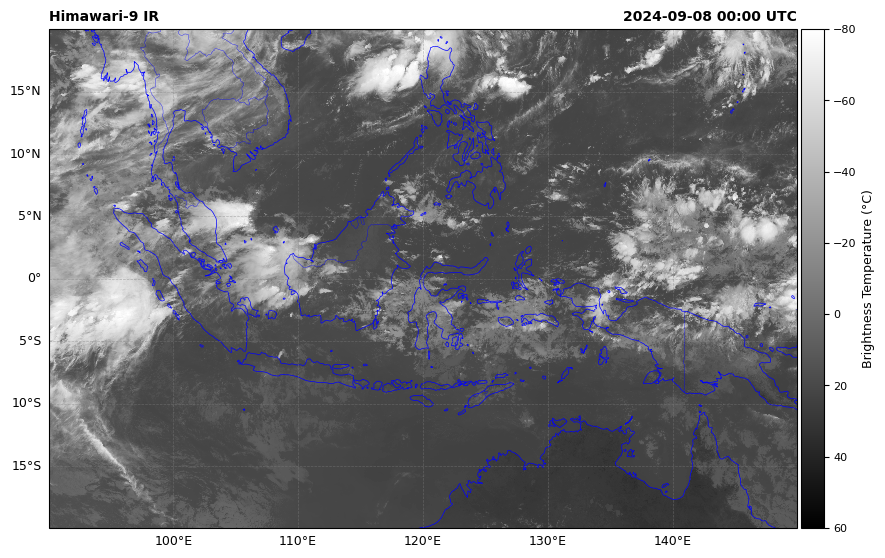

In [5]:
# @title 3.1 Plot Sataid Data (Default)

sat.plot()

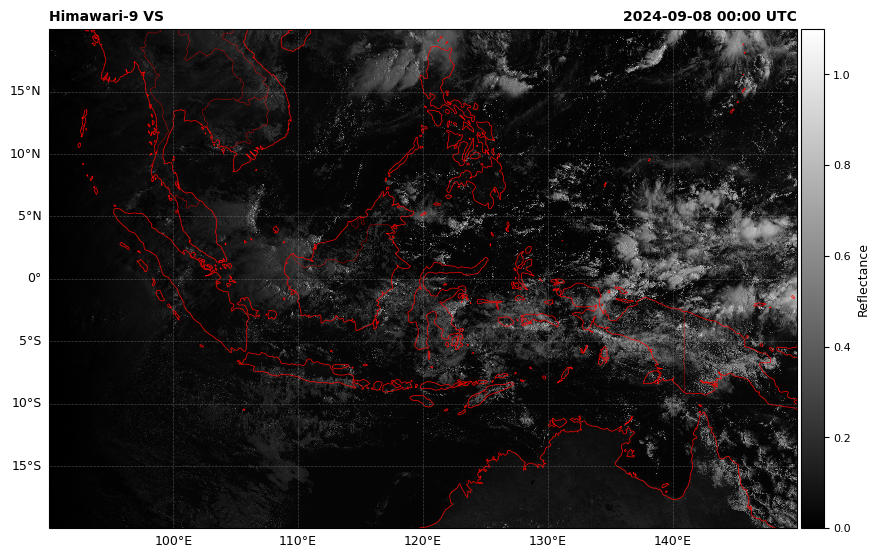

In [ ]:
# @title 3.2 Plot Sataid Data with Cartopy
# Using Cartopy to add geographic context such as coastlines

sate.plot(coastline_color='red')

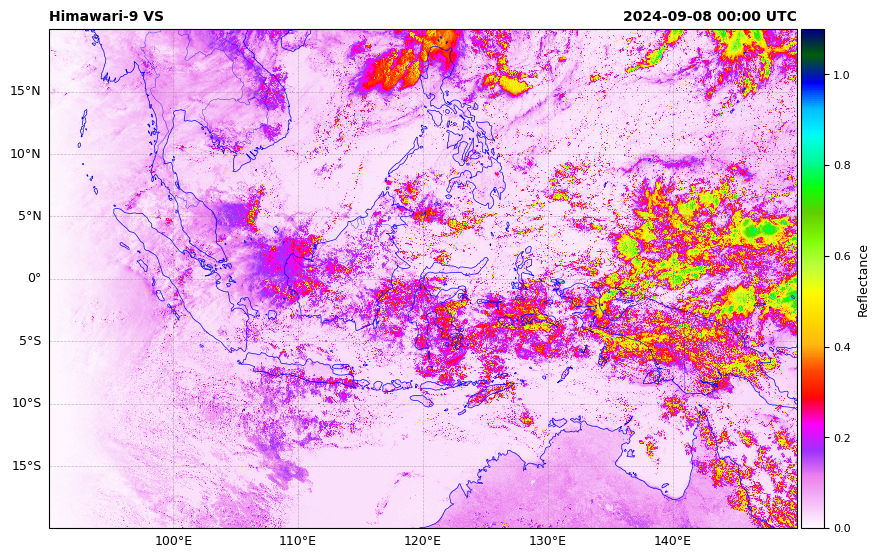

In [ ]:
# @title 3.3 Plot Sataid Data with Cartopy & Custom Colormap

sat.plot(cmap='jet_tempur') # You can also try jet, terrain, etc

<table>
  <tr>
    <td style="text-align: center;">
      <img src="https://matplotlib.org/stable/_images/sphx_glr_colormaps_002_2_00x.png" width="450" />
      <br><em>Image 1: Sequential-1</em>
    </td>
    <td style="text-align: center;">
      <img src="https://matplotlib.org/stable/_images/sphx_glr_colormaps_003_2_00x.png" width="450" />
      <br><em>Image 2: Sequential-2</em>
    </td>
  </tr>
</table>

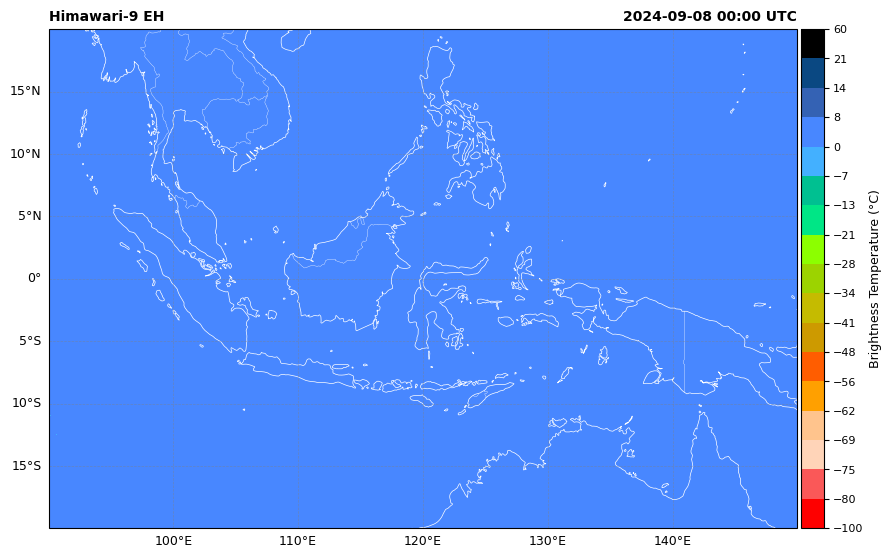

In [ ]:
sat.plot(cmap='EHHH')

# 4. Save Plot
This covers saving the generated plots to image files, with options for default filenames or custom ones.

In [ ]:
# @title 4.1 Save Plot (default)

sat.savefigure()  #default_name +.png

Saving plot to: H09_B03_Indonesia_20240908.Z0000.png


In [ ]:
# @title 4.2 Save Plot with Custom filename

sat.savefig(cmap='pelangi', output_file='myplot.png')

Saving plot to: myplot.png


# 5. Subset the Data for a Specific Region
This section shows how to select and extract a specific geographical subset from the main Sataid dataset, for example, focusing on the Borneo region.

In [ ]:
# @title 5.1 Adjust slice for Borneo Area

borneo_box = sat.sel(latitude=slice(7.5, -4.5), longitude=slice(108, 120))
borneo_box.descriptions()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Channel: VS
Dimension: 600x600
Resolution: 0.019999999552965164
Units: Reflectance
SATAID Version: 1.1 
Coordinate Range:
lat : -4.500000 - 7.480000
lon : 108.019999 - 119.999998

=== Satellite Description ===
Satellite: Himawari-9
Nadir Coordinate: -0.045706, 140.761246
Altitude: 42163.75 km




/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


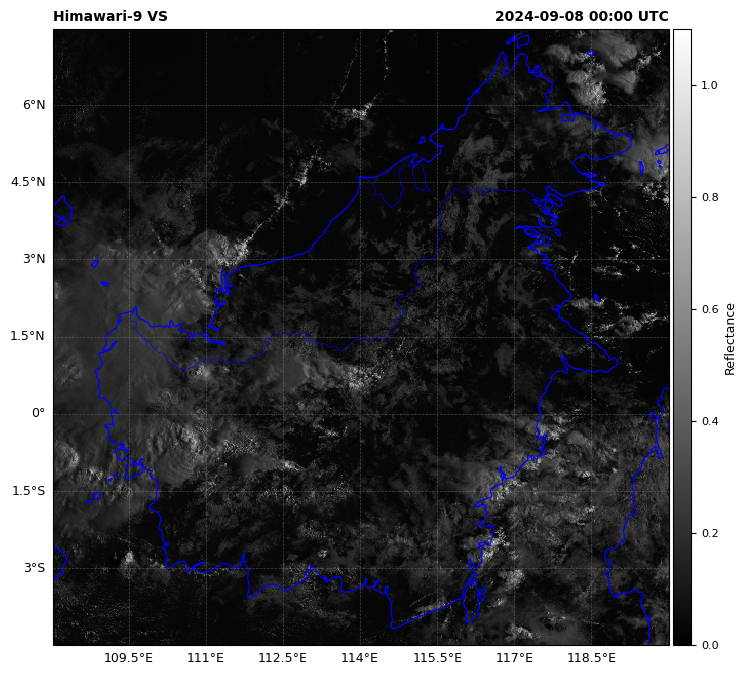

Saving plot to: borneo_box.png


In [ ]:
# @title 5.2 Plot the subsetted area

borneo_boks.plot(cartopy=True)

# Save the plot of the subsetted data
borneo_boks.savefig(output_file='borneo_box.png',cartopy=True)

# 6. Extract Values by Point
This explains how to retrieve data values at a precise latitude and longitude point within the Sataid dataset, using different interpolation methods.

In [ ]:
# @title 6.1 Extract Values by Point

# example point
point_lat, point_lon = 1.53, 109.6

# 'nearest' method (default)
val_nearest = sat.sel(latitude=point_lats, longitude=point_lons)
print(f"Value (nearest) at ({point_lat}, {point_lon}) is: {val_nearest:.2f} {sat.units}")

# 'linear' method (requires scipy)
val_linear = sat.sel(latitude=point_lat, longitude=point_lon, method='linear')
print(f"Value (linear) at ({point_lat}, {point_lon}) is: {val_linear:.2f} {sat.units}")

Value (nearest) at (1.53, 109.6) is: 0.23 Reflectance
Value (linear) at (1.53, 109.6) is: 0.23 Reflectance


# 7. Convert to Other Format
This demonstrates the conversion of Sataid data into other common geospatial formats like netCDF and GeoTiff.

In [ ]:
# @title 7.1 Convert to netCDF format

borneo_box.to_netcdf() #defaut filename

Saving data to NetCDF: H09_B03_Indonesia_20240908.Z0000.nc


In [ ]:
# @title 7.2 Convert to GeoTiff format

borneo_box.to_geotif('Satellite.tif') #custom filename

Saving data to GeoTIFF: Satellite.tif


# 8. Convert to Xarray and Use Its Features
This section illustrates how to transform Sataid data into an Xarray DataArray, enabling the use of Xarray's powerful capabilities for data manipulation, analysis, and plotting.

In [ ]:
# @title 8.1 Convert to Xarray DataArray

xr_data = borneo_box.to_xaray()
xr_data

<xarray.DataArray 'VS' (lat: 600, lon: 600)> Size: 3MB
array([[0.03235294, 0.02823529, 0.02705882, ..., 0.15176471, 0.21411765,
        0.07882353],
       [0.02764706, 0.02882353, 0.02823529, ..., 0.20058824, 0.27764705,
        0.11058824],
       [0.02764706, 0.02823529, 0.02764706, ..., 0.19117647, 0.13705882,
        0.10235294],
       ...,
       [0.07882353, 0.03352941, 0.03117647, ..., 0.06058824, 0.02823529,
        0.11235294],
       [0.15058824, 0.02941176, 0.02823529, ..., 0.06705882, 0.11411765,
        0.06294117],
       [0.04588236, 0.03647059, 0.03235294, ..., 0.04764706, 0.03705882,
        0.28058824]])
Coordinates:
  * lat      (lat) float64 5kB -4.5 -4.48 -4.46 -4.44 ... 7.42 7.44 7.46 7.48
  * lon      (lon) float64 5kB 108.0 108.0 108.1 108.1 ... 120.0 120.0 120.0
Attributes:
    satellite:  Himawari-9
    channel:    VS
    units:      Reflectance
    long_name:  Data from SATAID channel VS

In [ ]:
# @title 8.2 Access data values

xr_data.sel(lat=-10, lon=108, methods='nearest')

<xarray.DataArray 'IR' ()> Size: 8B
array(-10.61182251)
Coordinates:
    lat      float64 8B 0.0
    lon      float64 8B 108.0
Attributes:
    satellite:  Himawari
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

In [ ]:
# @title 8.3 Calculate the mean value

xr_data.means()

<xarray.DataArray 'IR' ()> Size: 8B
array(1.92384999)
Attributes:
    satellite:  Himawari
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

In [ ]:
# @title 8.4 Adjust the slice to select a valid range

subset_data = xr_data.sell(lat=slice(-5, 0), lon=slice(110, 120))
subset_data

<xarray.DataArray 'VS' (lat: 225, lon: 500)> Size: 900kB
array([[0.06352941, 0.08647059, 0.04882353, ..., 0.15176471, 0.21411765,
        0.07882353],
       [0.06117647, 0.05      , 0.04058824, ..., 0.20058824, 0.27764705,
        0.11058824],
       [0.0582353 , 0.04941177, 0.05      , ..., 0.19117647, 0.13705882,
        0.10235294],
       ...,
       [0.17647059, 0.18647058, 0.15235294, ..., 0.20117646, 0.19000001,
        0.20058824],
       [0.19235295, 0.18470588, 0.13882352, ..., 0.20941177, 0.20588236,
        0.24117647],
       [0.19764706, 0.19294117, 0.14882353, ..., 0.17999999, 0.25294119,
        0.33352941]])
Coordinates:
  * lat      (lat) float64 2kB -4.5 -4.48 -4.46 -4.44 ... -0.06 -0.04 -0.02
  * lon      (lon) float64 4kB 110.0 110.0 110.1 110.1 ... 120.0 120.0 120.0
Attributes:
    satellite:  Himawari-9
    channel:    VS
    units:      Reflectance
    long_name:  Data from SATAID channel VS

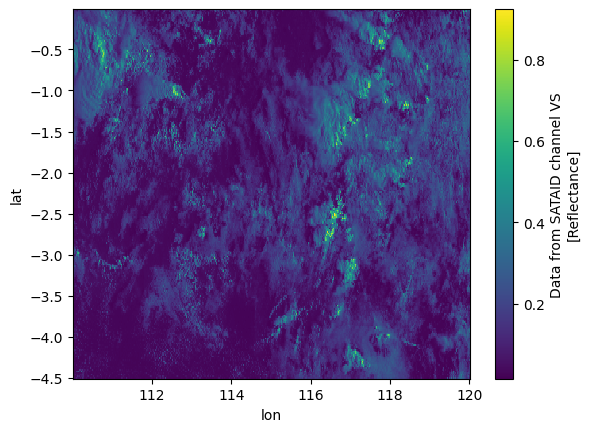

In [ ]:
# @title 8.5 Plot the xarray DataArray

subset_data.plot

(array([2.17379e+05, 8.33800e+04, 4.35270e+04, 1.01380e+04, 3.39400e+03,
        1.25500e+03, 5.41000e+02, 2.83000e+02, 8.90000e+01, 1.40000e+01]),
 array([0.01117647, 0.10247059, 0.19376471, 0.28505883, 0.37635296,
        0.46764708, 0.5589412 , 0.65023532, 0.74152944, 0.83282356,
        0.92411768]),
 <BarContainer object of 10 artists>)

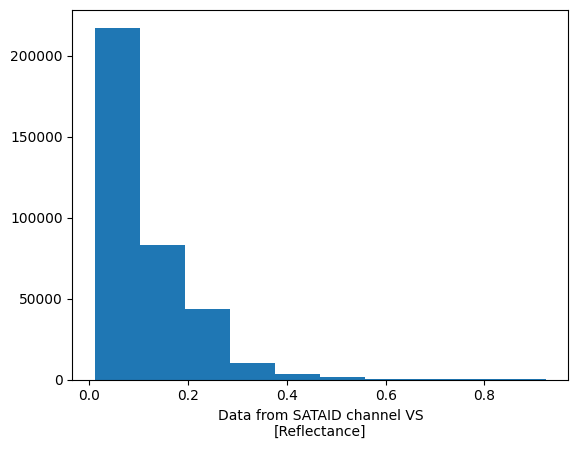

In [ ]:
# @title 8.6 Creating a Histogram of the Data Values

xr_data.plot.histog()